Method: Enumeration

env: Tensorflow (python 3.9.16)

In [1]:
%reset -f

In [2]:
import math
import itertools
import numpy as np
import networkx as nx
from scipy.stats import norm
from scipy.stats import gamma
import matplotlib.pyplot as plt
import time

Original network

In [ ]:

edges = [(1, 2), (2, 3), (1, 4), (2, 5), (3, 6),
         (4, 5), (5, 6), (4, 7), (5, 8), (6, 9),
         (7, 8), (8, 9)]
nodes = set(node for edge in edges for node in edge)
terminals = [1, 9]
num_nodes = len(nodes)
num_edges = len(edges)
num_terminals = len(terminals)
mm=num_nodes+num_edges
mm, 2**mm, nodes,num_nodes


(21, 2097152, {1, 2, 3, 4, 5, 6, 7, 8, 9}, 9)

In [4]:
m=mm-num_terminals
print(f"num m: {m}")
print(f"num 2^m: {2**m}")


num m: 19
num 2^m: 524288


In [ ]:
combinations = itertools.product([0, 1], repeat=mm)       
X = np.array(list(combinations))                            

for t in terminals:
    X[:, t-1] = 1   

print("X shape:", X.shape) 


X shape: (2097152, 21)


In [ ]:

# Y = []
# for state in X:
#     G = nx.Graph()
#     active_nodes = [node for node in nodes if state[node - 1] == 1] 
#     G.add_nodes_from(active_nodes)
#     for idx, (u, v) in enumerate(edges):
#         edge_state = state[num_nodes + idx] 
#         if edge_state == 1 and state[u - 1] == 1 and state[v - 1] == 1:
#             G.add_edge(u, v)

#     connected = all(nx.has_path(G, terminals[0], terminal) for terminal in terminals[1:]) 
#     Y.append(1 if connected else 0)
# Y = np.array(Y).reshape(-1,1)

# np.save('data_x_enumeration.npy',X)
# np.save('data_y_enumeration.npy',Y)


X=np.load('data_x_enumeration.npy')
Y=np.load('data_y_enumeration.npy')
X.shape, Y.shape


((2097152, 21), (2097152, 1))

In [ ]:

exp_nodes_lambda12 = [3, 5, 7]   
exp_nodes_lambda07 = [2, 4, 6, 8] 
infinite_nodes     = [1, 9]       

weibull_edges = [1, 2, 6, 7, 11, 12]  
lognorm_edges = [3, 4, 5, 8, 9, 10]    

n1 = len(exp_nodes_lambda12)
n2 = len(exp_nodes_lambda07)
n3 = len(weibull_edges)
n4 = len(lognorm_edges)
N = [n1, n2, n3, n4]

lambda1 = 1.2
lambda2 = 0.7
weibull_a = 1.5; weibull_b = 3.6
lognorm_mu = 1.5; lognorm_sigma = 2.6

def F_exp1(t):  
    return 1 - np.exp(-lambda1 * t)
def F_exp2(t): 
    return 1 - np.exp(-lambda2 * t)
def F_weibull(t):
    return 1 - np.exp(-((t / weibull_b) ** weibull_a))
def F_lognormal(t):
    return norm.cdf(np.log(t), lognorm_mu, lognorm_sigma)
F = [F_exp1, F_exp2, F_weibull, F_lognormal]

S = 4                  
S11 = [idx - 1 for idx in exp_nodes_lambda12]   
S22 = [idx - 1 for idx in exp_nodes_lambda07]   
S33 = [num_nodes + (idx - 1) for idx in weibull_edges]  
S44 = [num_nodes + (idx - 1) for idx in lognorm_edges]

# num_x = X.shape[0]
# l_count = np.zeros((num_x, S), dtype=int)
# l_count[:, 0] = X[:, S11].sum(axis=1)
# l_count[:, 1] = X[:, S22].sum(axis=1)
# l_count[:, 2] = X[:, S33].sum(axis=1)
# l_count[:, 3] = X[:, S44].sum(axis=1)
# np.save('data_l_count_enumeration.npy', l_count)

l_count = np.load('data_l_count_enumeration.npy')


In [ ]:
time1 =time.time()

def survival_signature(ls, l_count, y_train):
    ls_index = np.all(l_count == ls, axis=1)
    ls_num = np.sum(ls_index)
    ls_surv_num = np.sum(y_train[ls_index])
    if ls_num==0:
        ls_phi=0
    else:
        ls_phi = ls_surv_num/ls_num
    return ls_phi

def prop(ls, S, N, F, t_value):   
    p=1
    for s in range(S):
        m = N[s]
        l = ls[s]
        f = F[s]
        combi= math.comb(m, l)
        p=p*combi*(f(t_value)**(m-l))*((1-f(t_value))**l)
    return p


t_values = np.linspace(0.0001,3, 100)
R = 0
for l1 in range(n1+1):
    for l2 in range(n2+1):
        for l3 in range(n3+1):
            for l4 in range(n4+1):
                ls = [l1,l2,l3,l4]
                R+= survival_signature(ls, l_count, Y)*prop(ls, S, N, F, t_values)

time2 =time.time()
print(f"original survival time: {time2-time1} (s)")

np.save('R_exact.npy',R)



original survival time: 33.577638387680054 (s)


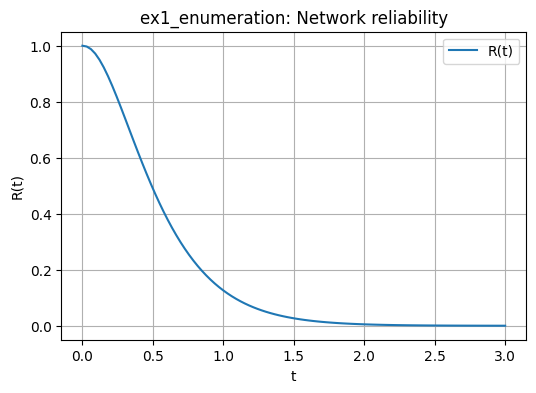

In [ ]:
R=np.load('R_exact.npy')
plt.figure(figsize=(6, 4))
plt.plot(t_values, R, label='R(t)')
plt.xlabel('t')
plt.ylabel('R(t)')
plt.title('ex1_enumeration: Network reliability')
plt.legend()
plt.grid(True)
# plt.savefig('1016result_exact_R1.png')
plt.show()

Variant network (remove node 7, edge 8, and edge 11)

In [ ]:

X[:, 6] = 0    
X[:, 16] = 0  
X[:, 19] = 0  
X2, indices, counts = np.unique(X, axis=0, return_index=True, return_counts=True)

Y2 = []
for state in X2:
    G = nx.Graph()
    active_nodes = [node for node in nodes if state[node - 1] == 1]    # 添加有效点，state[node - 1]节点编号1-18转为索引0-17
    G.add_nodes_from(active_nodes)
    for idx, (u, v) in enumerate(edges):
        edge_state = state[num_nodes + idx]  # 边状态在向量后半部分
        if edge_state == 1 and state[u - 1] == 1 and state[v - 1] == 1:
            G.add_edge(u, v)
    connected = all(nx.has_path(G, terminals[0], terminal) for terminal in terminals[1:]) # 检查终端节点之间的连通性
    Y2.append(1 if connected else 0)
Y2 = np.array(Y2).reshape(-1,1)


generate_variant_data_time: 0.967031717300415 (s)


((65536, 21), 65536)

In [ ]:

exp_nodes_lambda12_variant = [3, 5]        
exp_nodes_lambda07_variant = [2, 4, 6, 8] 
weibull_edges_variant = [1, 2, 6, 7, 12]   
lognorm_edges_variant = [3, 4, 5, 9, 10]   

n1_variant = len(exp_nodes_lambda12_variant)   # 2
n2_variant = len(exp_nodes_lambda07_variant)   # 4
n3_variant = len(weibull_edges_variant)        # 5
n4_variant = len(lognorm_edges_variant)        # 5
N2 = [n1_variant, n2_variant, n3_variant, n4_variant]

num_x2 = X2.shape[0]
l_count2 = np.zeros((num_x2, S), dtype=int)

S11_variant = [idx - 1 for idx in exp_nodes_lambda12_variant]
S22_variant = [idx - 1 for idx in exp_nodes_lambda07_variant]
S33_variant = [num_nodes + (idx - 1) for idx in weibull_edges_variant]
S44_variant = [num_nodes + (idx - 1) for idx in lognorm_edges_variant]

# l_count2[:, 0] = X2[:, S11_variant].sum(axis=1)
# l_count2[:, 1] = X2[:, S22_variant].sum(axis=1)
# l_count2[:, 2] = X2[:, S33_variant].sum(axis=1)
# l_count2[:, 3] = X2[:, S44_variant].sum(axis=1)
# np.save('data_l_count_enumeration_variant.npy', l_count2)

l_count2 = np.load('data_l_count_enumeration_variant.npy')


In [ ]:
time3 =time.time()
t_values = np.linspace(0.0001,3, 100)
R2 = 0
for l1 in range(n1+1):
    for l2 in range(n2_variant+1):
        for l3 in range(n3_variant+1):
            for l4 in range(n4+1):
                ls = [l1,l2,l3,l4]
                R2+= survival_signature(ls, l_count2, Y2)*prop(ls, S, N2, F, t_values)

print(f"variant survival time: {time.time()-time3} (s)")
np.save('R_exact_variant.npy',R2)


variant survival time: 0.9550468921661377 (s)


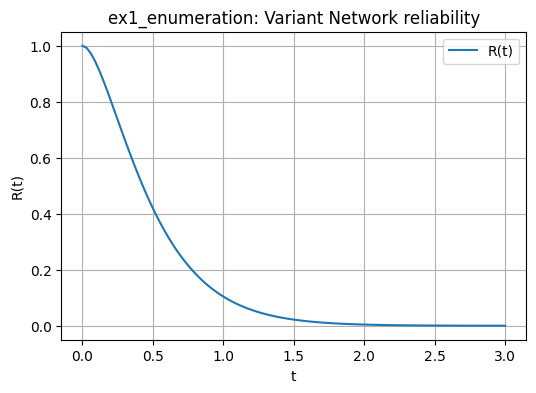

In [ ]:
# R2=np.load('R_exact_variant.npy')
plt.figure(figsize=(6, 4))
plt.plot(t_values, R2, label='R(t)')
plt.xlabel('t')
plt.ylabel('R(t)')
plt.title('ex1_enumeration: Variant Network reliability')
plt.legend()
plt.grid(True)
# plt.savefig('1016result_exact_R1_variant.png')
plt.show()